In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/hiv_preprocessed_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   age                             349 non-null    int64
 1   marital_status                  349 non-null    str  
 2   std                             349 non-null    str  
 3   educational_background          349 non-null    str  
 4   hiv_test_in_past_year           349 non-null    str  
 5   aids_education                  349 non-null    str  
 6   places_of_seeking_sex_partners  338 non-null    str  
 7   sexual_orientation              349 non-null    str  
 8   drug_taking                     349 non-null    str  
 9   result                          349 non-null    str  
dtypes: int64(1), str(9)
memory usage: 47.2 KB


In [3]:
df.head()

,age,marital_status,std,educational_background,hiv_test_in_past_year,aids_education,places_of_seeking_sex_partners,sexual_orientation,drug_taking,result
0,22,unmarried,no,college degree,yes,no,bar,heterosexual,yes,positive
1,20,unmarried,no,college degree,no,yes,NaN,heterosexual,no,negative
2,23,married,yes,college degree,no,yes,NaN,bisexual,no,negative
3,24,married,no,college degree,yes,yes,park,heterosexual,yes,positive
4,18,unmarried,yes,senior high school,yes,no,internet,heterosexual,yes,positive


In [4]:
num_cols  = ["age"]
cat_cols = df.select_dtypes(exclude='number').columns.drop(['result']).to_list()


### Target column

Text(0.5, 1.0, 'Distribution of Target')

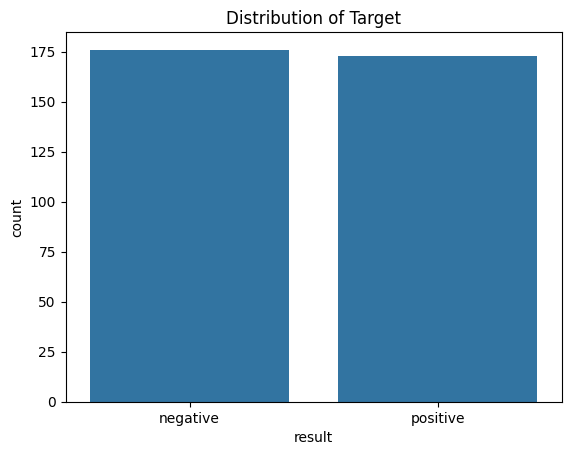

In [5]:
sns.barplot(df['result'].value_counts())
plt.title("Distribution of Target")

In [6]:
# check proportion of target
df['result'].value_counts(normalize=True)

result
negative    0.504298
positive    0.495702
Name: proportion, dtype: float64

### Numeric column

In [7]:
df[num_cols].describe()

,age
count,349.000000
mean,39.868195
std,18.225120
min,12.000000
25%,24.000000
50%,37.000000
75%,54.000000
max,80.000000


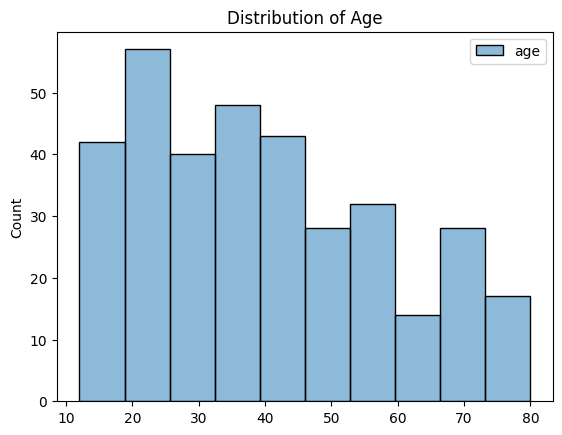

In [8]:
sns.histplot(df[num_cols])
plt.title(f"Distribution of Age")
plt.show()

### Catgorical Columns

Marital_Status
marital_status
unmarried     139
married       101
divorced       51
widowed        40
cohabiting     18
Name: count, dtype: int64


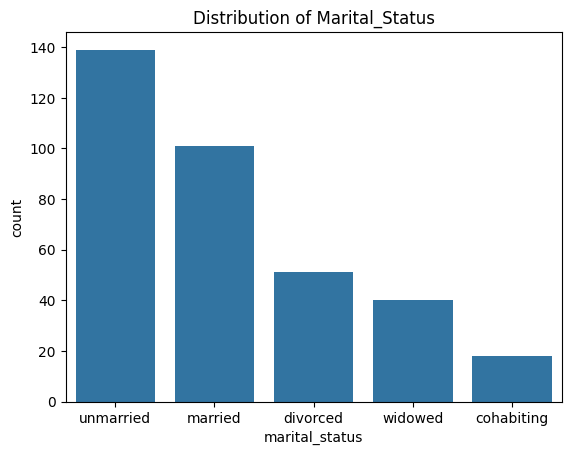

Std
std
no     184
yes    165
Name: count, dtype: int64


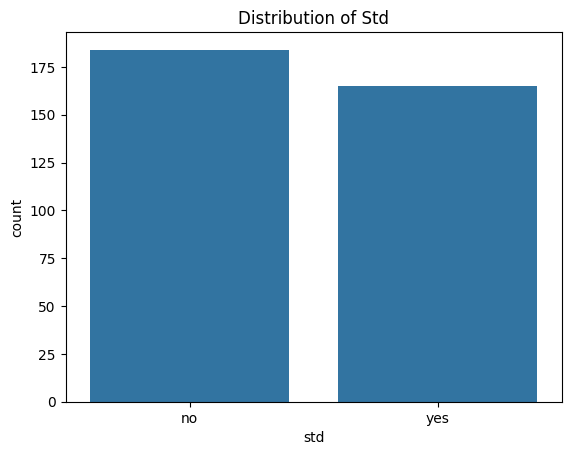

Educational_Background
educational_background
college degree        118
junior high school     69
senior high school     68
illiteracy             54
primary school         40
Name: count, dtype: int64


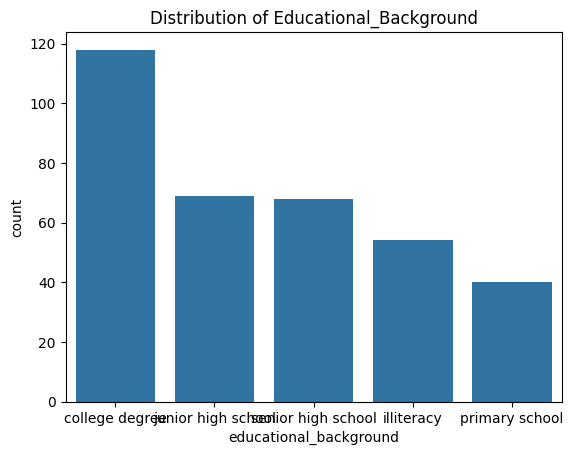

Hiv_Test_In_Past_Year
hiv_test_in_past_year
no     214
yes    135
Name: count, dtype: int64


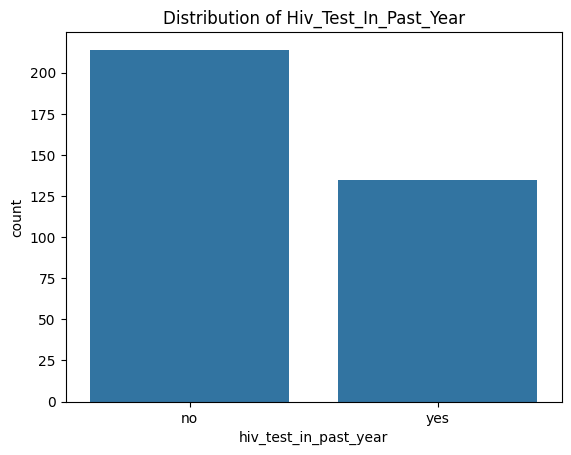

Aids_Education
aids_education
no     207
yes    142
Name: count, dtype: int64


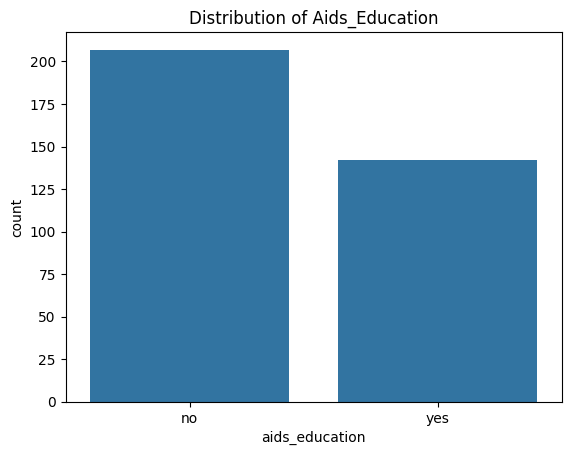

Places_Of_Seeking_Sex_Partners
places_of_seeking_sex_partners
internet       99
bar            74
public bath    74
park           54
others         37
Name: count, dtype: int64


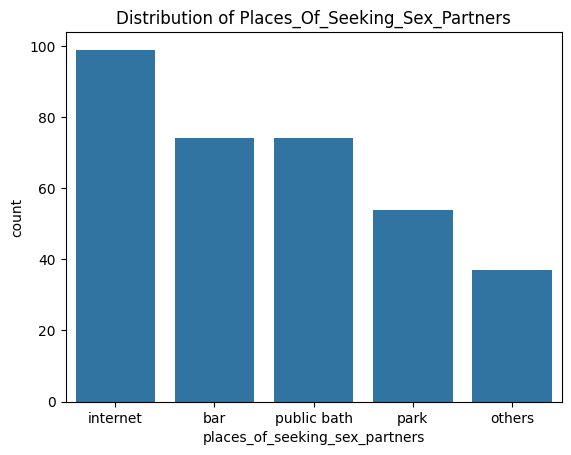

Sexual_Orientation
sexual_orientation
heterosexual    188
homosexual       86
bisexual         75
Name: count, dtype: int64


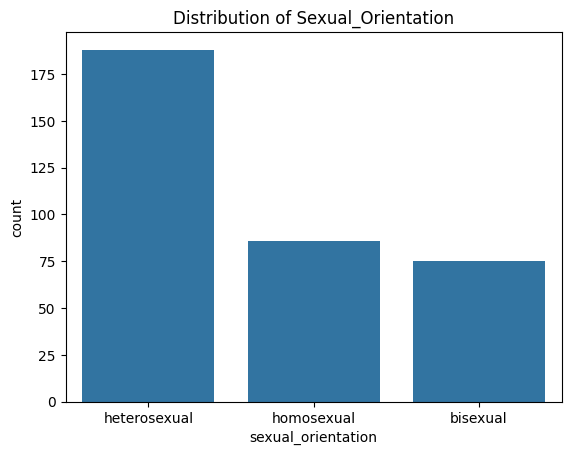

Drug_Taking
drug_taking
no     200
yes    149
Name: count, dtype: int64


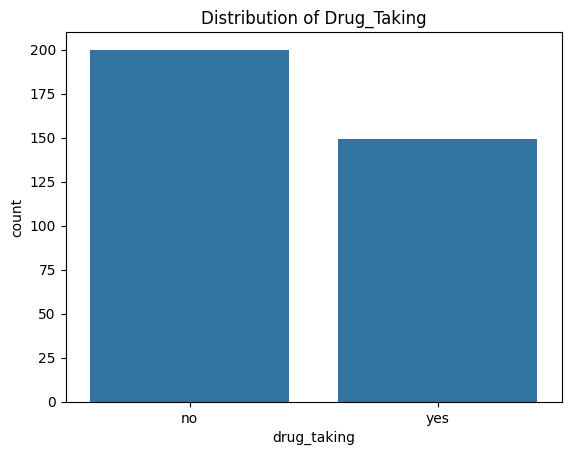

In [9]:
for col in cat_cols:
    cat_counts = df[col].value_counts()
    print(f"{col.title()}")
    print("==============")
    print(cat_counts)
    sns.barplot(cat_counts)
    plt.title(f"Distribution of {col.title()}")
    plt.show()

### Bivariate Analysis

In [10]:
df

,age,marital_status,std,educational_background,hiv_test_in_past_year,aids_education,places_of_seeking_sex_partners,sexual_orientation,drug_taking,result
0,22,unmarried,no,college degree,yes,no,bar,heterosexual,yes,positive
1,20,unmarried,no,college degree,no,yes,NaN,heterosexual,no,negative
2,23,married,yes,college degree,no,yes,NaN,bisexual,no,negative
3,24,married,no,college degree,yes,yes,park,heterosexual,yes,positive
4,18,unmarried,yes,senior high school,yes,no,internet,heterosexual,yes,positive
...,...,...,...,...,...,...,...,...,...,...
344,25,married,no,junior high school,no,no,public bath,heterosexual,yes,positive
345,46,cohabiting,yes,senior high school,yes,no,internet,homosexual,no,positive
346,24,married,no,college degree,yes,no,park,heterosexual,yes,positive
347,15,unmarried,no,junior high school,no,no,public bath,bisexual,no,negative


In [11]:
mapped = {
    "positive": 1,
    "negative":0
}

df['encoded'] = df['result'].map(mapped)

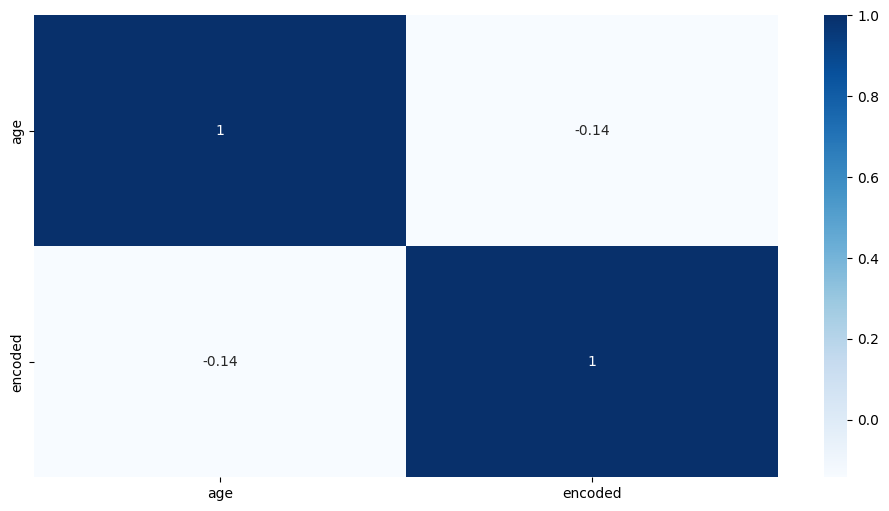

In [12]:
corr = df[num_cols + ["encoded"]].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap="Blues");

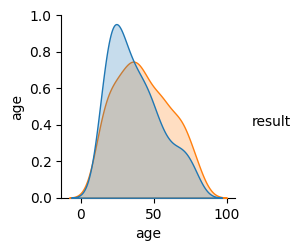

In [13]:
sns.pairplot(df[num_cols+["result"]], hue="result")

### Exploring average value by result

result
negative    42.443182
positive    37.248555
Name: age, dtype: float64


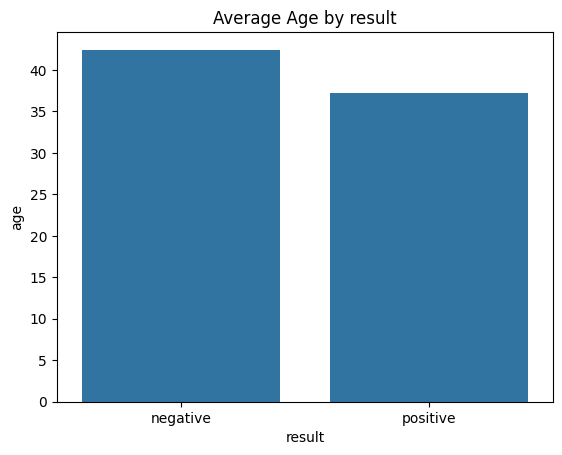

In [14]:
for col in num_cols:
    group_average = df.groupby("result")[col].mean()
    print(group_average)
    sns.barplot(group_average)
    plt.title(f"Average {col.title()} by result")
    plt.show()

### Exploring Result by category

marital_status
cohabiting    0.388889
divorced      0.490196
married       0.504950
unmarried     0.525180
widowed       0.425000
Name: encoded, dtype: float64


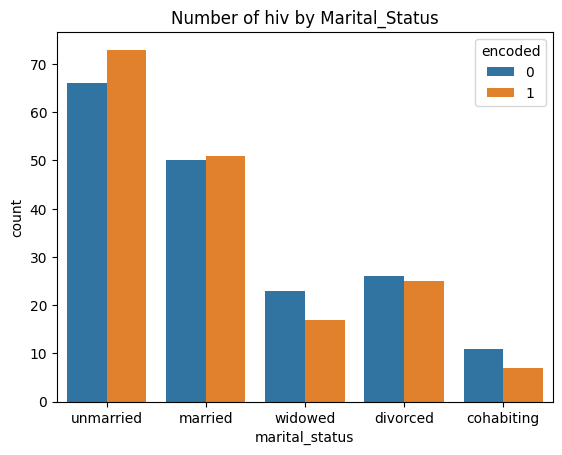

std
no     0.445652
yes    0.551515
Name: encoded, dtype: float64


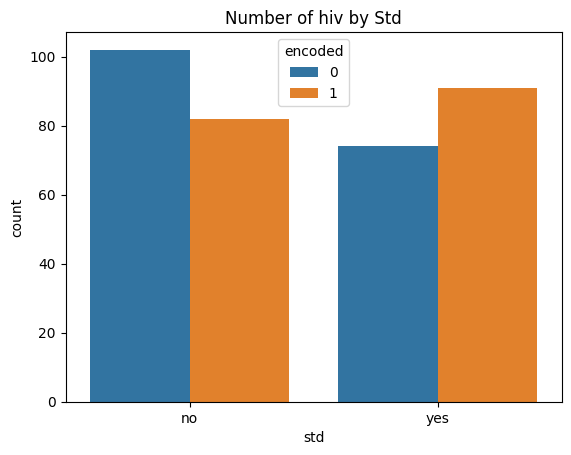

educational_background
college degree        0.474576
illiteracy            0.500000
junior high school    0.507246
primary school        0.475000
senior high school    0.529412
Name: encoded, dtype: float64


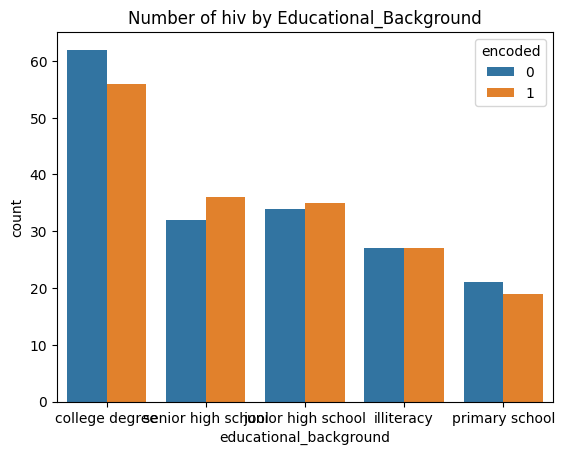

hiv_test_in_past_year
no     0.542056
yes    0.422222
Name: encoded, dtype: float64


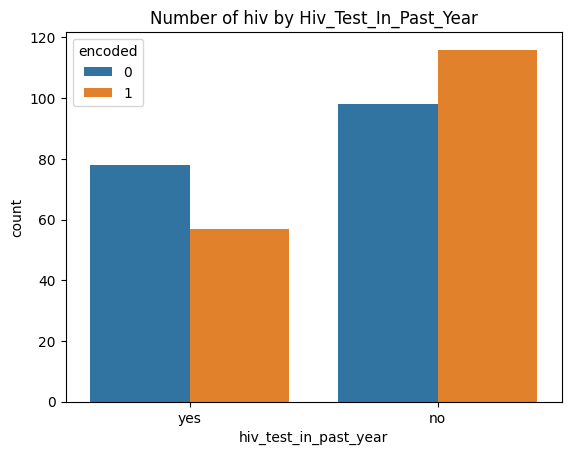

aids_education
no     0.579710
yes    0.373239
Name: encoded, dtype: float64


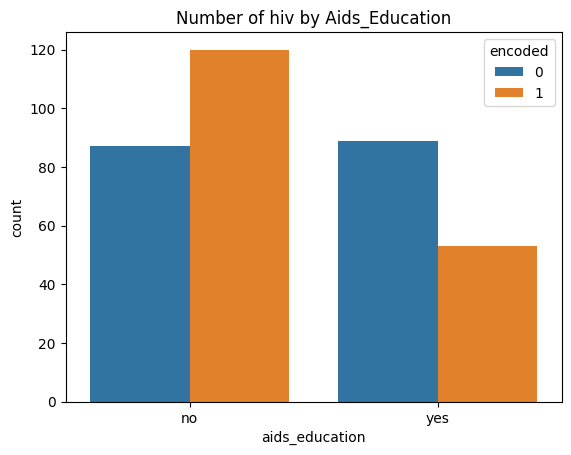

places_of_seeking_sex_partners
bar            0.202703
internet       0.808081
others         0.162162
park           0.351852
public bath    0.662162
Name: encoded, dtype: float64


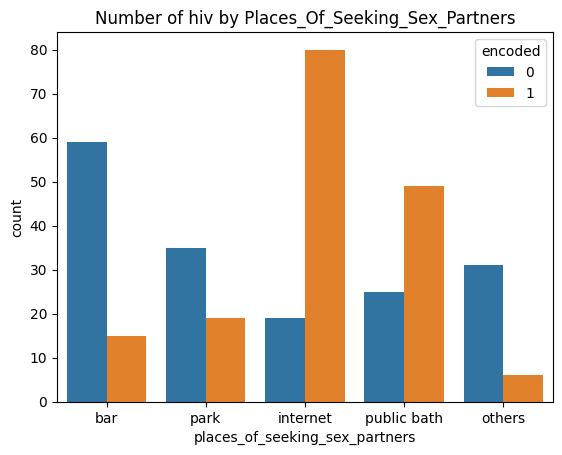

sexual_orientation
bisexual        0.506667
heterosexual    0.462766
homosexual      0.558140
Name: encoded, dtype: float64


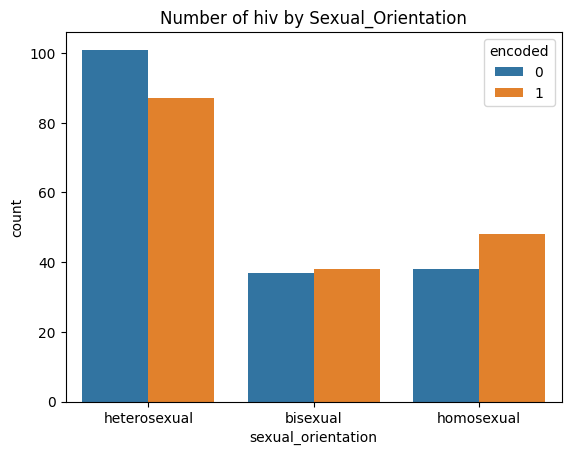

drug_taking
no     0.590000
yes    0.369128
Name: encoded, dtype: float64


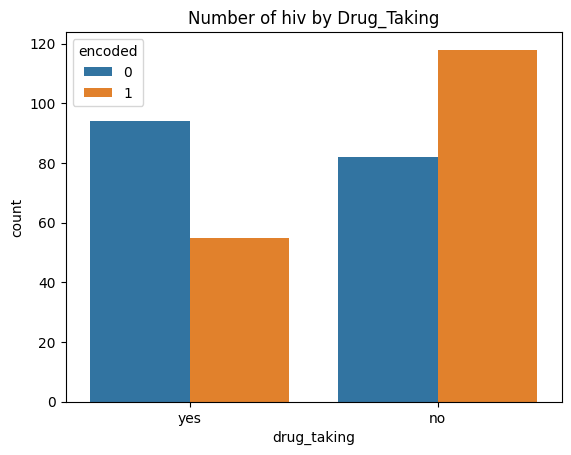

In [15]:
for col in cat_cols:
    group_hiv_rate = df.groupby(col)["encoded"].mean()
    print(group_hiv_rate)
    sns.countplot(x=df[col].astype(str), hue=df["encoded"])
    plt.title(f"Number of hiv by {col.title()}")
    plt.show()

### check mutual information score between categorical features and target

In [16]:
from sklearn.metrics import mutual_info_score

In [17]:
df.dropna(inplace=True)
df[cat_cols].apply(
    lambda feature: mutual_info_score(df['encoded'], feature)
).sort_values(ascending = False)

places_of_seeking_sex_partners    0.147381
drug_taking                       0.028839
aids_education                    0.022549
hiv_test_in_past_year             0.008158
std                               0.003953
marital_status                    0.003485
sexual_orientation                0.002771
educational_background            0.000748
dtype: float64